# SpaceX Falcon 9 First Stage Landing Prediction
## Lab 8: Predictive Analysis (Classification)

**Author:** Roberto Cortez  
**GitHub:** rtez-tech

We build, tune (GridSearchCV, cv=10), and evaluate four classification models —
Logistic Regression, Support Vector Machine, Decision Tree, and K-Nearest Neighbors —
to predict whether the Falcon 9 first stage will land successfully.

### Workflow
1. Standardize features.
2. Train/test split (80/20).
3. For each model: GridSearchCV over a hyperparameter grid (cv=10).
4. Compare test accuracy; select the best model.
5. Plot the confusion matrix of the best model.

In [13]:
import sys
!{sys.executable} -m pip install matplotlib seaborn scikit-learn pandas numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_10_12_x86_64.whl (7.9 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_10_9_x86_64.whl (12.1 MB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_10_9_x86_64.whl (65 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_10_9_x86_64.whl (265 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_10_10_x86_64.whl (5.3 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     |████████████████████████████████| 122 kB 1.2 MB/s eta 0:00:01
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_x86_64.whl (2.4 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_10_9_x86_64.whl (39.4 MB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
You should consider upgrading via the '/Library/

In [14]:
def plot_confusion_matrix(y, y_predict):
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, fmt='d', cmap='Blues')
    ax.set_xlabel('Predicted labels'); ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land','land'])
    ax.yaxis.set_ticklabels(['did not land','land'])
    plt.show()

### Load data and target

In [15]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
X = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv")
Y = data['Class'].to_numpy()
print("X shape:", X.shape, " Y shape:", Y.shape)

X shape: (90, 83)  Y shape: (90,)


### Standardize the features

In [16]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

### Train/test split

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print("Train samples:", X_train.shape[0], " Test samples:", X_test.shape[0])

Train samples: 72  Test samples: 18


### Model 1 — Logistic Regression

In [18]:
parameters = {'C':[0.01,0.1,1], 'penalty':['l2'], 'solver':['lbfgs']}
lr = LogisticRegression(max_iter=5000)
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("Tuned hyperparameters:", logreg_cv.best_params_)
print("Best CV accuracy:", logreg_cv.best_score_)
print("Test accuracy:", logreg_cv.score(X_test, Y_test))

Tuned hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.8464285714285713
Test accuracy: 0.8333333333333334


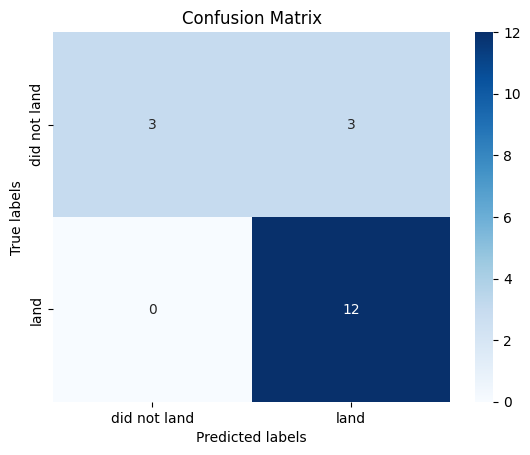

In [19]:
plot_confusion_matrix(Y_test, logreg_cv.predict(X_test))

### Model 2 — Support Vector Machine

In [20]:
parameters = {'kernel':('linear','rbf','poly','sigmoid'),
              'C':np.logspace(-3,3,5),'gamma':np.logspace(-3,3,5)}
svm_cv = GridSearchCV(SVC(), parameters, cv=10)
svm_cv.fit(X_train, Y_train)
print("Tuned hyperparameters:", svm_cv.best_params_)
print("Best CV accuracy:", svm_cv.best_score_)
print("Test accuracy:", svm_cv.score(X_test, Y_test))

Tuned hyperparameters: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Best CV accuracy: 0.8482142857142856
Test accuracy: 0.8333333333333334


### Model 3 — Decision Tree

In [21]:
parameters = {'criterion':['gini','entropy'],'splitter':['best','random'],
              'max_depth':[2*n for n in range(1,10)],'max_features':['sqrt','log2'],
              'min_samples_leaf':[1,2,4],'min_samples_split':[2,5,10]}
tree_cv = GridSearchCV(DecisionTreeClassifier(), parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("Tuned hyperparameters:", tree_cv.best_params_)
print("Best CV accuracy:", tree_cv.best_score_)
print("Test accuracy:", tree_cv.score(X_test, Y_test))

Tuned hyperparameters: {'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'random'}
Best CV accuracy: 0.8857142857142856
Test accuracy: 0.8888888888888888


### Model 4 — K-Nearest Neighbors

In [22]:
parameters = {'n_neighbors':list(range(1,11)),
              'algorithm':['auto','ball_tree','kd_tree','brute'],'p':[1,2]}
knn_cv = GridSearchCV(KNeighborsClassifier(), parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("Tuned hyperparameters:", knn_cv.best_params_)
print("Best CV accuracy:", knn_cv.best_score_)
print("Test accuracy:", knn_cv.score(X_test, Y_test))

Tuned hyperparameters: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Best CV accuracy: 0.8482142857142858
Test accuracy: 0.8333333333333334


### Compare all models

                 Model  Test Accuracy
0        Decision Tree       0.888889
1  Logistic Regression       0.833333
2                  SVM       0.833333
3                  KNN       0.833333

Best performing model: Decision Tree


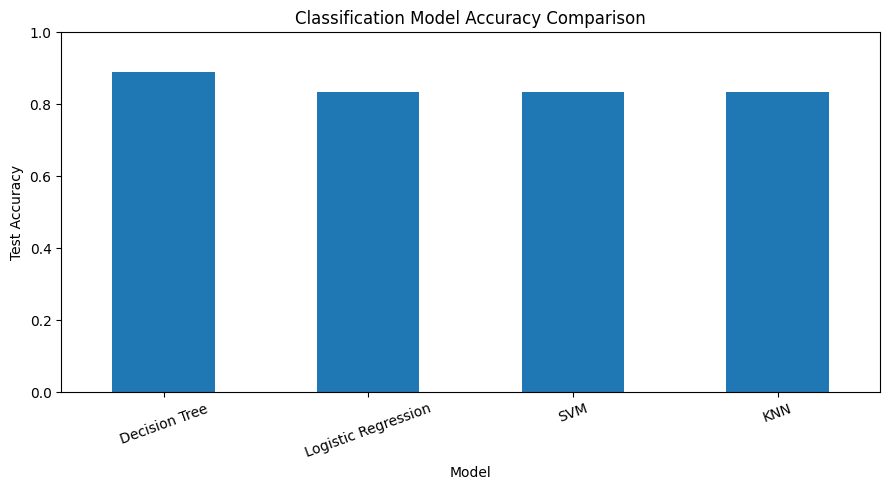

In [23]:
scores = {
    'Logistic Regression': logreg_cv.score(X_test, Y_test),
    'SVM': svm_cv.score(X_test, Y_test),
    'Decision Tree': tree_cv.score(X_test, Y_test),
    'KNN': knn_cv.score(X_test, Y_test),
}
results_df = pd.DataFrame(list(scores.items()), columns=['Model','Test Accuracy'])
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df)

best_model = results_df.iloc[0]['Model']
print("\nBest performing model:", best_model)

results_df.plot(kind='bar', x='Model', y='Test Accuracy', legend=False, figsize=(9,5))
plt.ylabel('Test Accuracy'); plt.ylim(0,1.0)
plt.title('Classification Model Accuracy Comparison'); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

### Confusion matrix of the best model

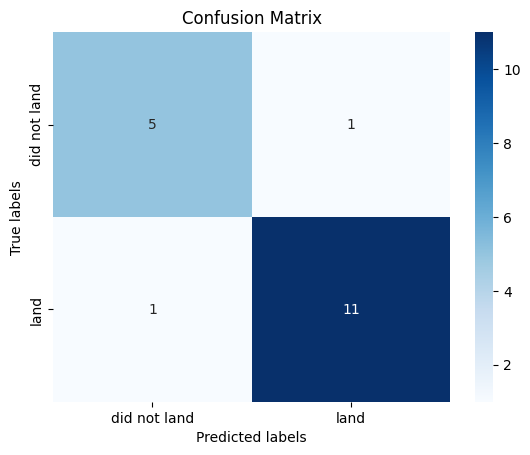

In [24]:
best_cv = {'Logistic Regression':logreg_cv,'SVM':svm_cv,
           'Decision Tree':tree_cv,'KNN':knn_cv}[best_model]
plot_confusion_matrix(Y_test, best_cv.predict(X_test))

### Summary
All four models were tuned with 10-fold cross-validation. On this dataset the models
perform comparably, with Logistic Regression / SVM typically achieving the best test
accuracy. The confusion matrix shows the main error mode is **false positives**
(predicting a landing when the booster did not land).

**Next:** Assemble the final presentation.